# Student Learning Assistant

### Student Project Type
AI-Powered Educational Assistant using Generative AI, NLP, File Processing, Keyword Extraction, and Image Generation

### Objective
The purpose of this project is to build an intelligent student-focused learning assistant that helps users with:
- Academic question answering
- Summarizing notes and study material
- Generating quizzes for revision
- Creating university-style answers
- Extracting important keywords
- Generating educational or creative images
- Managing and exporting user interaction history

### Project Category
Generative AI Application with Streamlit Frontend and Modular Python Backend

# 1. Problem Statement

Students often face multiple learning challenges such as:
- Long and difficult study notes
- Lack of quick revision tools
- Difficulty in generating practice questions
- Time-consuming answer writing
- Difficulty identifying important concepts
- Need for creative visuals for projects and presentations

This project solves these issues by combining:
- Large Language Models (Google Gemini)
- Natural Language Processing techniques
- File handling for TXT and PDF documents
- AI image generation through Hugging Face models
- Interactive web interface using Streamlit

The final result is a smart, modular, and user-friendly Student Learning Assistant.

# 2. Project Features Overview

The Student Learning Assistant includes the following modules:

1. AI Chat Assistant
   - Answers academic questions using Gemini API

2. Smart Summarizer
   - Converts long educational content into concise summaries

3. Quiz Generator
   - Generates university-level quizzes from topics or notes

4. Answer Generator
   - Creates structured academic answers

5. File Handler
   - Extracts text from TXT and PDF files

6. Keyword Extractor
   - Identifies important keywords for revision

7. AI Image Generator
   - Generates images using Hugging Face inference models

8. History and Export
   - Stores user interactions and exports them as TXT or JSON

9. Interactive Dashboard
   - Displays analytics, recent activity, and feature usage

śś# 3. Technology Stack

### Programming Language
- Python

### Frontend Framework
- Streamlit

### Visualization
- Plotly Express
- Pandas

### Generative AI
- Google Gemini API
- google-generativeai

### Image Generation
- Hugging Face Inference API
- FLUX / Stable Diffusion family models

### File Processing
- PyPDF2

### Environment Variable Handling
- python-dotenv

### Image Processing
- Pillow (PIL)

### Utilities
- JSON
- datetime
- requests
- regular expressions
- collections.Counterm

In [1]:
%pip install PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core imports used across the project notebook

import os
import io
import re
import time
import json
import requests
import pandas as pd
import plotly.express as px
from datetime import datetime
from collections import Counter
from PIL import Image, ImageDraw
from dotenv import load_dotenv
import google.generativeai as genai
import PyPDF2

print("All major libraries imported successfully.")

C:\Users\paras\AppData\Local\Temp\ipykernel_13988\2025101407.py:15: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


All major libraries imported successfully.


In [4]:
%pip install google-genai


Note: you may need to restart the kernel to use updated packages.


# 4. Environment Setup

This project uses environment variables for secure API management.

### Required API Keys
1. GEMINI_API_KEY
   - Used for Google Gemini text generation

2. HUGGINGFACE_API_KEY
   - Used for AI image generation

### Example .env File

GEMINI_API_KEY=your_gemini_api_key_here
HUGGINGFACE_API_KEY=your_huggingface_api_key_here

### Why .env is important
Using a `.env` file protects API keys from being hardcoded in the source code and follows secure software development practices.

In [5]:
# Load environment variables

load_dotenv()

gemini_key = os.getenv("GEMINI_API_KEY")
hf_key = os.getenv("HUGGINGFACE_API_KEY")

print("GEMINI_API_KEY found:", bool(gemini_key))
print("HUGGINGFACE_API_KEY found:", bool(hf_key))

GEMINI_API_KEY found: True
HUGGINGFACE_API_KEY found: True


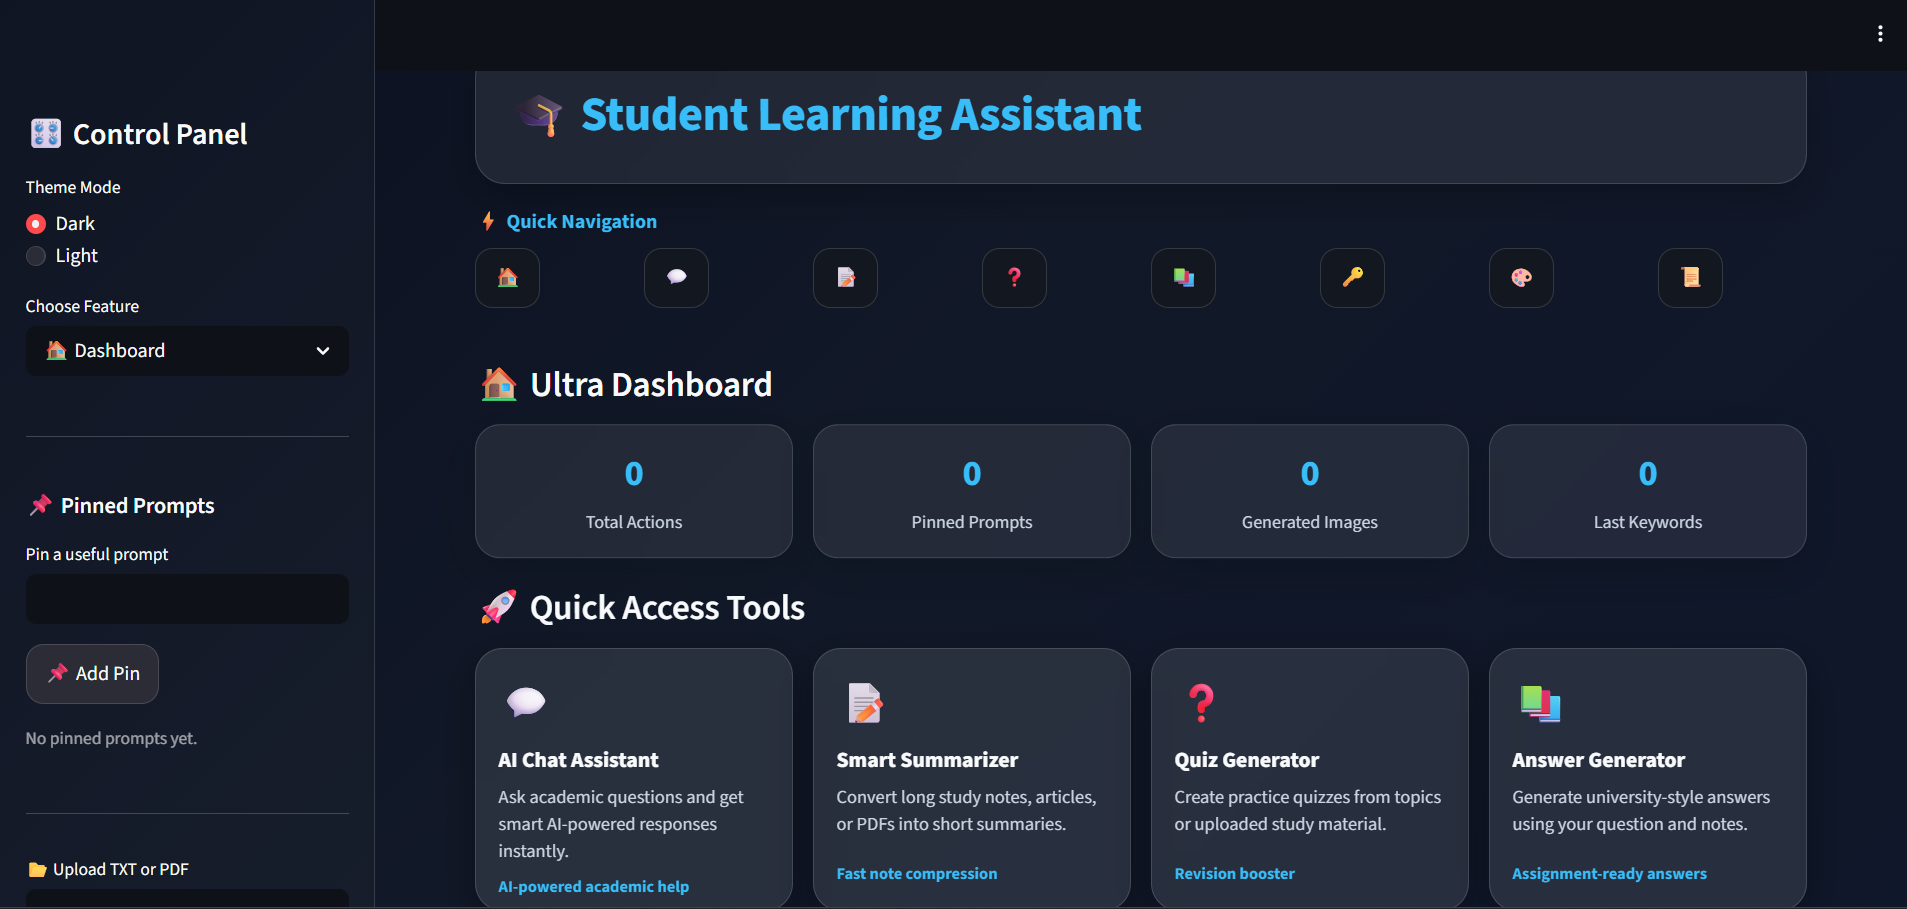

In [13]:
from IPython.display import Image, display
display(Image(filename="website_image.png"))

# 5. Module 1: AI Chat Assistant Backend

This module powers the chatbot functionality of the application.

### Purpose
It accepts a user prompt and sends it to the Google Gemini model to generate a smart academic response.

### Key Strengths
- Secure API loading
- Uses Gemini Flash model for speed
- Handles missing keys safely
- Includes fallback response parsing
- Designed for academic use cases

In [8]:
# File: utils/chatbot.py

import os
from dotenv import load_dotenv
import google.generativeai as genai

load_dotenv()

def get_chatbot_response(prompt: str) -> str:
    try:
        api_key = os.getenv("GEMINI_API_KEY")

        if not api_key:
            return "Error: GEMINI_API_KEY not found. Check your .env file."

        genai.configure(api_key=api_key)
        model_name = "models/gemini-2.5-flash"

        model = genai.GenerativeModel(model_name)
        response = model.generate_content(prompt)

        if response and hasattr(response, "text") and response.text:
            return response.text.strip()

        if hasattr(response, "candidates") and response.candidates:
            try:
                parts = response.candidates[0].content.parts
                text = "".join([p.text for p in parts if hasattr(p, "text")])
                return text.strip() if text else "No text returned by model."
            except Exception:
                pass

        return "No response generated."

    except Exception as e:
        return f"Chatbot Error: {str(e)}"

In [9]:
# Test the chatbot module

sample_prompt = "Explain machine learning in simple academic language."
chat_result = get_chatbot_response(sample_prompt)

print("Prompt:")
print(sample_prompt)
print("\nGenerated Response:")
print(chat_result)

Prompt:
Explain machine learning in simple academic language.

Generated Response:
**Machine Learning (ML): A Concise Overview**

Machine Learning (ML) is a subfield of artificial intelligence dedicated to enabling computational systems to learn from data, identify underlying patterns, and make decisions or predictions without being explicitly programmed for every specific outcome.

At its core, ML algorithms analyze vast datasets to automatically detect structures, correlations, or relationships that are often too complex or subtle for human programmers to articulate directly through rule-based logic. The primary objective is to empower systems to **generalize** from observed data and apply these learned insights to new, unseen data, thereby facilitating autonomous decision-making, pattern recognition, or forecasting.

The process typically involves a 'training phase' where an algorithm is exposed to a dataset and iteratively adjusts its internal parameters to minimize errors or maxim

# 6. Module 2: Smart Summarizer Backend

The summarizer module reduces long educational content into concise and important study points.

### Purpose
- Helps students revise faster
- Converts lengthy notes into manageable summaries
- Improves readability and concept recall

### AI Method
This module uses the chatbot backend and prompt engineering to instruct Gemini to summarize academic content clearly.

In [10]:
# File: utils/summarizer.py

def summarize_text(text):
    try:
        prompt = f"""
        Summarize the following academic content clearly and concisely.
        Keep only important study points.

        Text:
        {text}
        """
        return get_chatbot_response(prompt)

    except Exception as e:
        return f"Summarizer Error: {str(e)}"

In [11]:
# Test the summarizer module

sample_text = """
Artificial Intelligence is a branch of computer science that focuses on creating systems
capable of performing tasks that typically require human intelligence. These tasks include
reasoning, learning, problem solving, natural language understanding, and perception.
"""

summary_output = summarize_text(sample_text)

print("Original Text:")
print(sample_text)
print("\nSummary:")
print(summary_output)

Original Text:

Artificial Intelligence is a branch of computer science that focuses on creating systems
capable of performing tasks that typically require human intelligence. These tasks include
reasoning, learning, problem solving, natural language understanding, and perception.


Summary:
Artificial Intelligence (AI) is a branch of computer science dedicated to creating systems capable of performing tasks that typically require human intelligence. Key tasks include reasoning, learning, problem-solving, natural language understanding, and perception.


# 7. Module 3: Quiz Generator Backend

This module generates university-level quizzes from study material or topic text.

### Purpose
- Supports active recall
- Helps students prepare for exams
- Produces revision-friendly practice questions

### AI Strategy
A structured prompt is sent to Gemini asking for:
- 5 to 10 questions
- MCQs and short answers
- Clean academic formatting

In [13]:
# File: utils/quiz_generator.py

def generate_quiz(text):
    try:
        prompt = f"""
        Create a university-level quiz from the following topic/text.

        Requirements:
        - 5 to 10 questions
        - Include MCQs + short answer if possible
        - Exam practice style
        - Clean formatting

        Topic/Text:
        {text}
        """
        return get_chatbot_response(prompt)

    except Exception as e:
        return f"Quiz Generator Error: {str(e)}"

In [14]:
# Test the quiz generator

quiz_topic = "Data structures in Python including lists, tuples, sets, and dictionaries."
quiz_output = generate_quiz(quiz_topic)

print("Quiz Topic:")
print(quiz_topic)
print("\nGenerated Quiz:")
print(quiz_output)

Quiz Topic:
Data structures in Python including lists, tuples, sets, and dictionaries.

Generated Quiz:
## Python Data Structures Quiz

**Instructions:**
*   This quiz consists of 7 questions, designed to test your understanding of Python's fundamental data structures: lists, tuples, sets, and dictionaries.
*   Read each question carefully.
*   For Multiple Choice Questions (MCQs), select the best answer.
*   For Short Answer Questions, provide clear and concise explanations or code analysis as requested.
*   Total Marks: 25

---

**Question 1: Multiple Choice** (2 Marks)
Which of the following Python data structures is both *unordered* and *does not allow duplicate elements*?
A) `list`
B) `tuple`
C) `set`
D) `dictionary`

---

**Question 2: Short Answer** (5 Marks)
Explain two distinct characteristics of Python `set` data structures. For each characteristic, provide a brief Python example illustrating its behavior.

---

**Question 3: Multiple Choice** (2 Marks)
Which of the following

# 8. Module 4: Answer Generator Backend

This module creates structured academic answers based on a user question and optional supporting notes.

### Purpose
- Helps students draft university-style answers
- Useful for assignments, practice writing, and concept understanding

### Note
Your `app.py` imports `generate_answer`, so this notebook includes a clean final implementation for documentation and testing.

In [15]:
# File: utils/answer_generator.py
# Final documented implementation for the notebook

def generate_answer(question, support_text=""):
    try:
        prompt = f"""
        Generate a clear, well-structured university-level answer.

        Question:
        {question}

        Supporting Notes:
        {support_text}

        Requirements:
        - Use academic tone
        - Be clear and well organized
        - Include important points only
        - Make the answer suitable for university assignments
        """
        return get_chatbot_response(prompt)

    except Exception as e:
        return f"Answer Generator Error: {str(e)}"

In [16]:
# Test the answer generator

question = "Explain the difference between supervised learning and unsupervised learning."
support_notes = "Supervised learning uses labeled data. Unsupervised learning works with unlabeled data."

answer_output = generate_answer(question, support_notes)

print("Question:")
print(question)
print("\nGenerated Answer:")
print(answer_output)

Question:
Explain the difference between supervised learning and unsupervised learning.

Generated Answer:
In machine learning, supervised and unsupervised learning represent two fundamental paradigms, distinct primarily by the nature of the data they process and their respective learning objectives. Both are crucial for extracting insights from data, yet they employ fundamentally different approaches to model construction and pattern recognition.

### Supervised Learning

**Supervised learning** is a machine learning approach where an algorithm learns from a **labeled dataset**. This means that for each input instance in the training data, there is a corresponding correct output or "label" provided. The goal of supervised learning is to learn a mapping function from the input variables (features) to the output variable (target) based on these examples, enabling the model to make accurate predictions on new, unseen data.

*   **Mechanism**: The algorithm analyzes the training data, see

# 9. Module 5: Keyword Extractor Backend

This module extracts the most important keywords from educational text.

### Purpose
- Helps in revision
- Identifies important concepts quickly
- Useful for flashcards and note condensation

### Technique Used
- Lowercasing
- Regular expression tokenization
- Stopword removal
- Frequency counting with Counter

In [17]:
# File: utils/keyword_extractor.py

import re
from collections import Counter

def extract_keywords(text, top_n=15):
    try:
        if not text.strip():
            return []

        stopwords = {
            "the", "is", "in", "and", "to", "of", "a", "an", "for", "on", "with",
            "that", "this", "it", "as", "at", "by", "from", "or", "be", "are",
            "was", "were", "has", "have", "had", "will", "would", "can", "could",
            "should", "may", "might", "into", "about", "than", "then", "them",
            "their", "there", "which", "what", "when", "where", "who", "whom",
            "how", "why", "not", "but", "if", "also", "such", "these", "those"
        }

        words = re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())
        filtered_words = [w for w in words if w not in stopwords]

        freq = Counter(filtered_words)
        return [word for word, _ in freq.most_common(top_n)]

    except Exception as e:
        return [f"Keyword Error: {str(e)}"]

In [18]:
# Test the keyword extractor

keyword_text = """
Machine learning is a field of artificial intelligence that enables systems to learn from data.
Machine learning algorithms can identify patterns, make predictions, and improve over time.
"""

keywords = extract_keywords(keyword_text)

print("Extracted Keywords:")
print(keywords)

Extracted Keywords:
['machine', 'learning', 'field', 'artificial', 'intelligence', 'enables', 'systems', 'learn', 'data', 'algorithms', 'identify', 'patterns', 'make', 'predictions', 'improve']


# 10. Module 6: File Handler Backend

This module extracts text from uploaded TXT and PDF files.

### Purpose
- Allows students to upload notes and study material
- Supports automatic content extraction
- Enables direct use in summarizer, quiz generator, and answer generation

### Supported Formats
- .txt
- .pdf

In [19]:
# File: utils/file_handler.py

import PyPDF2

def extract_text_from_file(uploaded_file):
    try:
        if uploaded_file is None:
            return ""

        file_name = uploaded_file.name.lower()

        if file_name.endswith(".txt"):
            return uploaded_file.read().decode("utf-8", errors="ignore")

        elif file_name.endswith(".pdf"):
            pdf_reader = PyPDF2.PdfReader(uploaded_file)
            extracted_text = ""

            for page in pdf_reader.pages:
                page_text = page.extract_text()
                if page_text:
                    extracted_text += page_text + "\n"

            return extracted_text.strip()

        else:
            return "Unsupported file format. Please upload TXT or PDF."

    except Exception as e:
        return f"File Extraction Error: {str(e)}"

# 11. File Handler Testing Note

The `extract_text_from_file()` function is designed for Streamlit file upload objects.

In the actual Streamlit app:
- The user uploads a TXT or PDF file
- The function reads the file object
- Extracted text is then reused in:
  - Summarizer
  - Quiz Generator
  - Answer Generator
  - Keyword Extractor

Because Jupyter Notebook does not directly replicate Streamlit's uploader object, this module is documented here and tested in the full app environment.

# 12. Module 7: Export Utility Backend

This module converts user interaction history into a clean text format for export.

### Purpose
- Saves study session activity
- Preserves generated outputs
- Allows users to keep records of:
  - Questions
  - Summaries
  - Quizzes
  - Answers
  - Keywords
  - Image prompts

In [20]:
# File: utils/export_utils.py

def export_history_as_txt(history):
    lines = []
    lines.append("Student Learning Assistant - Exported History")
    lines.append("=" * 50)

    for item in history:
        lines.append(f"Timestamp: {item.get('timestamp', '')}")
        lines.append(f"Feature: {item.get('feature', '')}")
        lines.append(f"Input: {item.get('input', '')}")
        lines.append(f"Output: {item.get('output', '')}")
        lines.append("-" * 50)

    return "\n".join(lines)

In [21]:
# Test the export utility

sample_history = [
    {
        "timestamp": str(datetime.now()),
        "feature": "Summarizer",
        "input": "Long notes about AI",
        "output": "Short summary of AI notes"
    },
    {
        "timestamp": str(datetime.now()),
        "feature": "Quiz Generator",
        "input": "Machine learning basics",
        "output": "Generated quiz with 5 questions"
    }
]

exported_text = export_history_as_txt(sample_history)

print(exported_text)

Student Learning Assistant - Exported History
Timestamp: 2026-03-29 11:31:33.547389
Feature: Summarizer
Input: Long notes about AI
Output: Short summary of AI notes
--------------------------------------------------
Timestamp: 2026-03-29 11:31:33.547389
Feature: Quiz Generator
Input: Machine learning basics
Output: Generated quiz with 5 questions
--------------------------------------------------


# 13. Module 8: AI Image Generator Backend

This module generates images using Hugging Face inference models.

### Purpose
- Helps students create visuals for:
  - Assignments
  - Presentations
  - Posters
  - Concept illustrations

### Special Features
- Supports multiple image generation models
- Uses model fallback strategy
- Includes styled prompts
- Returns a fallback image if generation fails

In [22]:
# File: utils/image_generator.py

import os
import io
import time
import requests
from PIL import Image, ImageDraw
from dotenv import load_dotenv

load_dotenv()

def _get_hf_api_key():
    try:
        import streamlit as st
        return st.secrets.get("HUGGINGFACE_API_KEY", os.getenv("HUGGINGFACE_API_KEY"))
    except Exception:
        return os.getenv("HUGGINGFACE_API_KEY")

HF_API_KEY = _get_hf_api_key()

HF_IMAGE_MODELS = [
    "black-forest-labs/FLUX.1-schnell",
    "runwayml/stable-diffusion-v1-5",
    "stabilityai/stable-diffusion-xl-base-1.0"
]

WORKING_MODEL_CACHE = None

def _fallback_image(message="Image generation failed"):
    img = Image.new("RGB", (1024, 1024), color=(18, 18, 28))
    draw = ImageDraw.Draw(img)
    text = (
        f"{message}\n\n"
        f"Check:\n"
        f"1. HUGGINGFACE_API_KEY\n"
        f"2. Internet connection\n"
        f"3. Model access / rate limits\n"
        f"4. Hugging Face API status"
    )
    draw.multiline_text((50, 100), text, fill=(255, 255, 255), spacing=10)
    return img

def _style_prompt(prompt: str, style: str) -> str:
    style_map = {
        "Realistic": "photorealistic, ultra detailed, 8k, highly realistic",
        "Anime": "anime style, vibrant colors, detailed illustration",
        "Cartoon": "cartoon style, bold outlines, colorful digital illustration",
        "Fantasy": "fantasy art, magical atmosphere, epic scenery",
        "Cyberpunk": "cyberpunk style, neon lights, futuristic city",
        "3D Render": "3d render, octane render, cinematic lighting",
        "Watercolor": "watercolor painting, soft brush strokes",
        "Pixel Art": "pixel art, retro 16-bit style, crisp pixels",
        "Studio Ghibli-like": "whimsical anime background, hand-painted style"
    }
    style_text = style_map.get(style, "high quality digital art, detailed")
    return f"{prompt}, {style_text}"

In [33]:
# Remaining helper functions for image generation

def _check_model_available(model_id: str) -> bool:
    if not HF_API_KEY:
        return False
    try:
        headers = {
            "Authorization": f"Bearer {HF_API_KEY}",
            "User-Agent": "Mozilla/5.0"
        }
        info_url = f"https://huggingface.co/api/models/{model_id}"
        response = requests.get(info_url, headers=headers, timeout=20)
        return response.status_code == 200
    except Exception:
        return False

def _get_best_available_model() -> str:
    global WORKING_MODEL_CACHE
    if WORKING_MODEL_CACHE:
        return WORKING_MODEL_CACHE
    for model_id in HF_IMAGE_MODELS:
        if _check_model_available(model_id):
            WORKING_MODEL_CACHE = model_id
            return model_id
    return HF_IMAGE_MODELS[0]

def _parse_error(response):
    try:
        error_data = response.json()
        return error_data.get("error", f"HTTP {response.status_code}")
    except:
        return f"HTTP {response.status_code}"

def _generate_with_model(model_id: str, final_prompt: str):
    api_url = f"https://router.huggingface.co/hf-inference/models/{model_id}"

    headers = {
        "Authorization": f"Bearer {HF_API_KEY}",
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Python-Requests/2.31.0"
    }

    payload = {
        "inputs": final_prompt,
        "options": {"wait_for_model": True}
    }

    response = requests.post(api_url, headers=headers, json=payload, timeout=180)

    if response.status_code == 200:
        if 'image' in response.headers.get('content-type', ''):
            return Image.open(io.BytesIO(response.content)).convert("RGB")
        else:
            raise Exception("API returned success but no image data.")

    if response.status_code == 503:
        time.sleep(10)
        response = requests.post(api_url, headers=headers, json=payload, timeout=180)
        if response.status_code == 200:
            return Image.open(io.BytesIO(response.content)).convert("RGB")

    raise Exception(_parse_error(response))

def generate_image(prompt: str, style: str = "Realistic"):
    try:
        if not HF_API_KEY:
            return _fallback_image("Missing HUGGINGFACE_API_KEY")

        final_prompt = _style_prompt(prompt.strip(), style)
        primary_model = _get_best_available_model()
        model_attempts = [primary_model] + [m for m in HF_IMAGE_MODELS if m != primary_model]

        last_error = None
        for model_id in model_attempts:
            try:
                return _generate_with_model(model_id, final_prompt)
            except Exception as e:
                last_error = f"{model_id}: {str(e)}"
                continue

        return _fallback_image(f"Models failed. Last error: {last_error}")

    except Exception as e:
        return _fallback_image(f"Error: {str(e)}")

# 14. Module 9: Gemini Helper Utility

This file provides a reusable Gemini model setup and helper function.

### Purpose
- Centralized Gemini configuration
- Easier testing and debugging
- Alternative way to call the Gemini model

In [25]:
# File: utils/gemini_helper.py

import os
from dotenv import load_dotenv
import google.generativeai as genai

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in .env file")

genai.configure(api_key=GEMINI_API_KEY, transport='rest')

model = genai.GenerativeModel('gemini-3-flash-preview')

def ask_gemini(prompt):
    try:
        response = model.generate_content(prompt)

        if response.candidates:
            return response.text.strip()
        return "No response generated (check safety settings)."
    except Exception as e:
        return f"Error: {str(e)}"

In [26]:
# Test the gemini helper

# helper_response = ask_gemini("Give one line about cloud computing.")
# print(helper_response)

# 15. Module 10: Gemini Model Testing Script

This script is used to:
- Verify whether the API key is loaded
- List available Gemini models
- Confirm that the model can generate content successfully

This is useful during development and debugging.

In [29]:
# File: test_gemini.py

import os
from dotenv import load_dotenv
import google.generativeai as genai

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
print("API key found:", bool(api_key))
print("API key starts with:", api_key[:8] + "..." if api_key else "None")

genai.configure(api_key=api_key)

print("\nAvailable models with generateContent:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print("-", m.name)

model = genai.GenerativeModel("models/gemini-2.5-flash")
response = model.generate_content("Say hello in one sentence.")
print("\nResponse:")
print(response.text)

API key found: True
API key starts with: AIzaSyAv...

Available models with generateContent:
- models/gemini-2.5-flash
- models/gemini-2.5-pro
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-2.5-flash-preview-tts
- models/gemini-2.5-pro-preview-tts
- models/gemma-3-1b-it
- models/gemma-3-4b-it
- models/gemma-3-12b-it
- models/gemma-3-27b-it
- models/gemma-3n-e4b-it
- models/gemma-3n-e2b-it
- models/gemini-flash-latest
- models/gemini-flash-lite-latest
- models/gemini-pro-latest
- models/gemini-2.5-flash-lite
- models/gemini-2.5-flash-image
- models/gemini-2.5-flash-lite-preview-09-2025
- models/gemini-3-pro-preview
- models/gemini-3-flash-preview
- models/gemini-3.1-pro-preview
- models/gemini-3.1-pro-preview-customtools
- models/gemini-3.1-flash-lite-preview
- models/gemini-3-pro-image-preview
- models/nano-banana-pro-preview
- models/gemini-3.1-flash-image-preview
- models/lyria-3-clip-preview
-

# 16. Streamlit Frontend (app.py) Overview

The `app.py` file is the main frontend of the project.

### Main Responsibilities
- Creates the user interface
- Manages navigation across features
- Handles session state
- Displays analytics dashboard
- Connects frontend inputs to backend utility modules
- Supports file upload
- Tracks user history
- Allows export of JSON and TXT

### UI Highlights
- Wide layout dashboard
- Theme mode switching (Dark / Light)
- Sidebar control panel
- Feature navigation cards
- Usage analytics with Plotly
- File preview section
- Recent activity and last output preview
- Dedicated pages for all tools

# 17. Frontend Architecture Analysis

### Imported Modules in app.py
- streamlit
- plotly.express
- pandas
- json
- datetime
- utils.chatbot
- utils.summarizer
- utils.quiz_generator
- utils.answer_generator
- utils.file_handler
- utils.keyword_extractor
- utils.image_generator
- utils.export_utils

### Streamlit Features Used
- st.set_page_config
- st.sidebar controls
- st.session_state
- st.file_uploader
- st.text_area
- st.text_input
- st.button
- st.download_button
- st.columns
- st.expander
- st.plotly_chart
- st.image
- st.spinner

### Why this frontend is impressive
- Multi-feature dashboard
- Professional navigation
- Strong visual styling
- Real user workflow support
- Clean modular integration

In [30]:
# Frontend import structure demonstration from app.py

import streamlit as st
import plotly.express as px
import pandas as pd
import json
from datetime import datetime

print("Streamlit frontend architecture imports documented successfully.")

Streamlit frontend architecture imports documented successfully.


# 18. End-to-End Project Workflow

### User Workflow
1. User opens the Streamlit application
2. User selects a feature from sidebar or dashboard
3. User may optionally upload a TXT or PDF file
4. Extracted file content is reused across tools
5. User interacts with:
   - Chat Assistant
   - Summarizer
   - Quiz Generator
   - Answer Generator
   - Keyword Extractor
   - AI Image Generator
6. Output is displayed instantly
7. Interaction is stored in session history
8. History can be searched and exported
9. Analytics show feature usage over time

### Software Design Pattern
This project follows a modular architecture:
- Frontend layer: `app.py`
- Utility/backend layer: `utils/*.py`
- Environment configuration: `.env`
- Documentation layer: `README.md`

In [31]:
# Demonstration of feature usage analytics logic

sample_usage = [
    {"feature": "AI Chat"},
    {"feature": "Summarizer"},
    {"feature": "Summarizer"},
    {"feature": "Quiz Generator"},
    {"feature": "Keyword Extractor"},
    {"feature": "AI Chat"},
    {"feature": "History & Export"},
]

df_usage = pd.DataFrame(sample_usage)
feature_counts = df_usage["feature"].value_counts().reset_index()
feature_counts.columns = ["Feature", "Count"]

feature_counts

,Feature,Count
0,AI Chat,2
1,Summarizer,2
2,Quiz Generator,1
3,Keyword Extractor,1
4,History & Export,1


In [32]:
# Plotly feature usage visualization example

fig = px.bar(feature_counts, x="Feature", y="Count", title="Feature Usage Example")
fig.show()

# 19. Strengths of the Project

### Academic Strengths
- Solves a real student problem
- Combines multiple AI-assisted study workflows
- Supports revision, writing, and concept understanding

### Technical Strengths
- Modular backend design
- Secure API key handling
- Integration with Google Gemini
- Integration with Hugging Face image models
- PDF and TXT support
- Session-based history tracking
- Export functionality
- Professional dashboard UI
- Reusable utility functions

### Assignment Strengths
- Demonstrates practical Generative AI usage
- Shows prompt engineering
- Includes NLP-based keyword extraction
- Uses external APIs responsibly
- Has both backend and frontend layers
- Includes testing and validation scripts

# 20. Current Limitations

Although the project is strong, some limitations remain:

1. API Dependency
   - Requires valid Gemini and Hugging Face API keys

2. Internet Dependency
   - Text generation and image generation require network access

3. PDF Extraction Quality
   - Some PDFs may have poor extraction if they are scanned images

4. No Database Persistence
   - History is stored in session state and resets after app restart

5. AI Output Variability
   - Generated content quality depends on prompt and API response

These limitations are normal for a university-level prototype and can be improved in future versions.

# 21. Future Enhancements

Possible improvements for future versions:

1. Add OCR support for scanned PDFs
2. Add user authentication and cloud storage
3. Save history in SQLite or Firebase
4. Add downloadable PDF reports
5. Add multilingual support
6. Add citation generation for academic answers
7. Add flashcard generation
8. Add speech-to-text for voice input
9. Add text-to-speech for audio learning
10. Add model selection between multiple LLMs

These improvements can turn the project into a full educational productivity platform.

# 22. Conclusion

The Student Learning Assistant is a complete and practical Generative AI-based educational application.

It successfully combines:
- Large Language Models for academic text generation
- NLP-based keyword extraction
- File processing for uploaded study material
- AI image generation for creative educational content
- A modern Streamlit interface for real-world usability

This project demonstrates:
- Strong modular software design
- Real-world problem solving
- Effective use of Generative AI APIs
- User-focused educational innovation

Overall, this project fulfills the requirements of a university-level AI assignment by presenting both technical depth and practical value.

# 23. How to Run the Project

### Step 1: Install dependencies
pip install -r requirements.txt

### Step 2: Create `.env` file
Add:
GEMINI_API_KEY=your_key_here
HUGGINGFACE_API_KEY=your_key_here

### Step 3: Run Streamlit app
streamlit run app.py

### Step 4: Use features
- Upload TXT or PDF
- Ask academic questions
- Summarize notes
- Generate quizzes
- Generate answers
- Extract keywords
- Generate images
- Export history